In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("..")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## random

In [3]:
# Load a NAB time series from files that are present in this repository.
from pathlib import Path

file = "ec2_request_latency_system_failure"
DATA_ROOT = Path("../data/NAB")
csv_path = DATA_ROOT / f"{file}.csv"
processed_path = DATA_ROOT / f"processed_{file}.parquet"

if processed_path.exists():
    df_nab = pd.read_parquet(processed_path)
else:
    df_nab = pd.read_csv(csv_path, parse_dates=["timestamp"])
    df_nab["target"] = 0

values = df_nab[["value"]].to_numpy(dtype="float32")
y = df_nab["target"].to_numpy(dtype="int64")
split_idx = int(len(values) * 0.7)
tr = values[:split_idx]
te = values[split_idx:]


In [4]:
tr.shape

(2822, 1)

In [5]:
te.shape

(1210, 1)

In [6]:
y.shape

(4032,)

In [7]:
tr.max(), tr.min()

(51.972, 30.482)

In [8]:
np.r_[tr, te]


array([[45.868],
       [47.606],
       [42.58 ],
       ...,
       [22.864],
       [66.26 ],
       [30.962]], dtype=float32)

In [9]:
y.sum()

0

In [10]:
y.sum() / len(y) * 100

0.0

In [11]:
tr.repeat(24, 1)

array([[45.868, 45.868, 45.868, ..., 45.868, 45.868, 45.868],
       [47.606, 47.606, 47.606, ..., 47.606, 47.606, 47.606],
       [42.58 , 42.58 , 42.58 , ..., 42.58 , 42.58 , 42.58 ],
       ...,
       [45.376, 45.376, 45.376, ..., 45.376, 45.376, 45.376],
       [45.61 , 45.61 , 45.61 , ..., 45.61 , 45.61 , 45.61 ],
       [45.634, 45.634, 45.634, ..., 45.634, 45.634, 45.634]],
      dtype=float32)

In [12]:
import torch


class Args:
    model = ""


args = Args()


def convert_to_windows(data, w_size):
    data = torch.as_tensor(data, dtype=torch.float32)
    windows = []
    for i, _ in enumerate(data):
        if i >= w_size:
            w = data[i - w_size : i]
        else:
            w = torch.cat([data[0].repeat(w_size - i, 1), data[0:i]])
        windows.append(w if "TranAD" in args.model or "Attention" in args.model else w.reshape(-1))
    return torch.stack(windows)


In [13]:
torch.as_tensor(tr[0]).repeat(4)


tensor([45.8680, 45.8680, 45.8680, 45.8680])

In [14]:
convert_to_windows(tr[:10], 4)


tensor([[45.8680, 45.8680, 45.8680, 45.8680],
        [45.8680, 45.8680, 45.8680, 45.8680],
        [45.8680, 45.8680, 45.8680, 47.6060],
        [45.8680, 45.8680, 47.6060, 42.5800],
        [45.8680, 47.6060, 42.5800, 46.0300],
        [47.6060, 42.5800, 46.0300, 44.9920],
        [42.5800, 46.0300, 44.9920, 45.2380],
        [46.0300, 44.9920, 45.2380, 45.7520],
        [44.9920, 45.2380, 45.7520, 46.4760],
        [45.2380, 45.7520, 46.4760, 42.7520]])

## Approximate sigmoid

In [15]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def polynomial_approximation(x, coefficients):
    # Evaluate the polynomial using Horner's method
    result = 0
    for i in range(len(coefficients)):
        result = result * x + coefficients[i]
    return result


def approximate_sigmoid(degree):
    # Generate training data
    x = np.linspace(-5, 5, 100)
    y = sigmoid(x)

    # Perform polynomial regression
    coefficients = np.polyfit(x, y, degree)
    print(", ".join(f"{x:.6f}" for x in coefficients))

    # Generate test data for plotting
    x_test = np.linspace(-10, 10, 100)
    y_test = polynomial_approximation(x_test, coefficients)

    # Plot the original sigmoid function and the approximation
    plt.plot(x, y, label="Sigmoid Function")
    plt.plot(x_test, y_test, label="Polynomial Approximation (degree={})".format(degree))
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.title("Approximating Sigmoid with Polynomial")
    plt.show()

only between -5 and 5, then cutoff at 1

-0.004391, 0.000000, 0.197440, 0.500000


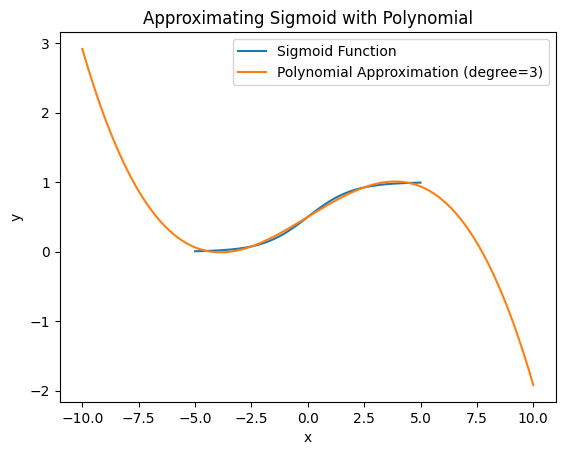

In [16]:
# Example usage
approximate_sigmoid(degree=3)

In [17]:
a = np.arange(-5, 5)

In [18]:
b = a * a * a * (-0.004391) + a * (0.197440) + (0.500000);

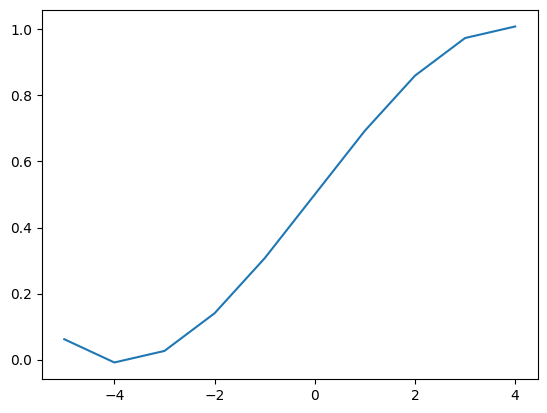

In [19]:
plt.plot(a, b)

# OLD

## matmul for vitis

In [20]:
# multiply m1 by m2
m1 = np.zeros(shape=(6, 5))
m2 = np.zeros(shape=(5, 4))
for i in range(6):
    for j in range(5):
        m1[i, j] = i * 5 + j

for i in range(5):
    for j in range(4):
        m2[i, j] = i * 4 + j + 1

In [21]:
res = []
for r in m1:
    res.append(", ".join([f"{x:.0f}" for x in r]))
print(",\n".join(res))

0, 1, 2, 3, 4,
5, 6, 7, 8, 9,
10, 11, 12, 13, 14,
15, 16, 17, 18, 19,
20, 21, 22, 23, 24,
25, 26, 27, 28, 29


In [22]:
res = []
for r in m2:
    res.append(", ".join([f"{x:.0f}" for x in r]))
print(",\n".join(res))

1, 2, 3, 4,
5, 6, 7, 8,
9, 10, 11, 12,
13, 14, 15, 16,
17, 18, 19, 20


In [23]:
m3 = np.matmul(m1, m2)

In [24]:
res = []
for r in m3:
    res.append(", ".join([f"{x:.0f}" for x in r]))
print(",\n".join(res))

130, 140, 150, 160,
355, 390, 425, 460,
580, 640, 700, 760,
805, 890, 975, 1060,
1030, 1140, 1250, 1360,
1255, 1390, 1525, 1660


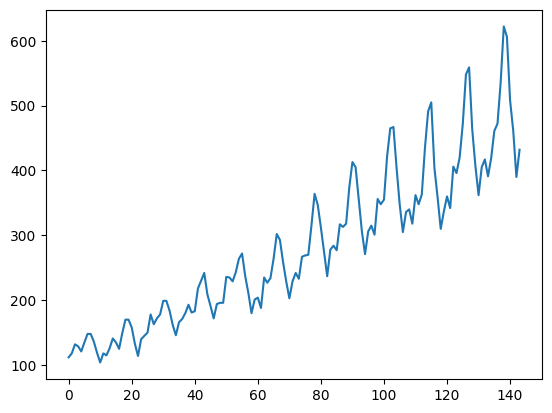

In [25]:
df = pd.read_csv("airline-passengers.csv")
timeseries = df[["Passengers"]].values.astype("float32")

plt.plot(timeseries)
plt.show()


In [26]:
# train-test split for time series
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]

In [27]:
import torch


def create_dataset(dataset, lookback):
    """Transform a time series into a prediction dataset

    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset) - lookback):
        feature = dataset[i : i + lookback]
        target = dataset[i + 1 : i + lookback + 1]
        X.append(feature)
        y.append(target)
    return torch.tensor(X), torch.tensor(y)

In [28]:
lookback = 5
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([91, 5, 1]) torch.Size([91, 5, 1])
torch.Size([43, 5, 1]) torch.Size([43, 5, 1])


/tmp/ipykernel_148286/813615327.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  return torch.tensor(X), torch.tensor(y)


In [29]:
import torch.nn as nn


class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(50, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x

In [30]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.utils.data as data

# df = pd.read_csv('airline-passengers.csv')
# timeseries = df[["Passengers"]].values.astype('float32')

# # train-test split for time series
# train_size = int(len(timeseries) * 0.67)
# test_size = len(timeseries) - train_size
# train, test = timeseries[:train_size], timeseries[train_size:]

In [31]:
def create_dataset(dataset, lookback):
    """Transform a time series into a prediction dataset

    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset) - lookback):
        feature = dataset[i : i + lookback]
        target = dataset[i + 1 : i + lookback + 1]
        X.append(feature)
        y.append(target)
    return torch.tensor(X), torch.tensor(y)

In [32]:
import torch.optim as optim
import torch.utils.data as data

lookback = 4
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)


class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(50, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x


model = AirModel()
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle=True, batch_size=8)


Epoch 0: train RMSE 225.9873, test RMSE 425.2260
Epoch 5: train RMSE 224.0074, test RMSE 423.2323
Epoch 10: train RMSE 220.2299, test RMSE 419.2405
Epoch 15: train RMSE 217.6235, test RMSE 416.5428


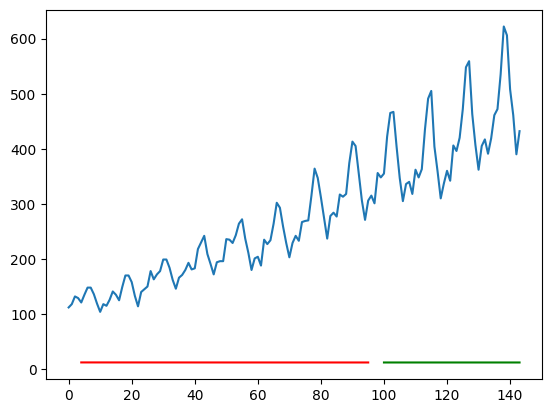

In [33]:
n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # Validation
    if epoch % 5 != 0:
        continue
    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = torch.sqrt(loss_fn(y_pred, y_train)).item()
        y_pred = model(X_test)
        test_rmse = torch.sqrt(loss_fn(y_pred, y_test)).item()
    print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

with torch.no_grad():
    # shift train predictions for plotting
    train_plot = np.ones_like(timeseries) * np.nan
    y_pred = model(X_train)
    y_pred = y_pred[:, -1, :].numpy()
    train_plot[lookback:train_size] = y_pred
    # shift test predictions for plotting
    test_plot = np.ones_like(timeseries) * np.nan
    y_pred = model(X_test)[:, -1, :].numpy()
    test_plot[train_size + lookback : len(timeseries)] = y_pred
# plot
plt.plot(timeseries)
plt.plot(train_plot, c="r")
plt.plot(test_plot, c="g")
plt.show()


In [34]:
X_batch.shape

torch.Size([4, 4, 1])

In [35]:
b = next(iter(loader))

In [36]:
len(b)

2

In [37]:
b[1].shape

torch.Size([8, 4, 1])

In [38]:
b[0].shape

torch.Size([8, 4, 1])

## TranAD format

In [39]:
DATA_DIR = Path("../data/NAB")
sorted(p.name for p in DATA_DIR.glob("*.csv"))


['ambient_temperature_system_failure.csv',
 'cpu_utilization_asg_misconfiguration.csv',
 'ec2_request_latency_system_failure.csv',
 'machine_temperature_system_failure.csv',
 'nyc_taxi.csv',
 'rogue_agent_key_hold.csv',
 'rogue_agent_key_updown.csv',
 'speed_7578.csv']

In [40]:
from pathlib import Path

DATA_DIR = Path("../data/NAB")


In [41]:
df_ambient = pd.read_csv(DATA_DIR / "ambient_temperature_system_failure.csv", parse_dates=["timestamp"])
tr = df_ambient[["value"]].to_numpy(dtype="float32")
y = np.zeros(len(tr), dtype="int64")


In [42]:
tr

array([[69.88084 ],
       [71.22023 ],
       [70.87781 ],
       ...,
       [72.04656 ],
       [71.825226],
       [72.58409 ]], dtype=float32)

In [43]:
y

array([0, 0, 0, ..., 0, 0, 0])

## attention example

https://stackoverflow.com/questions/65642832/inputs-to-the-nn-multiheadattention

https://stackoverflow.com/questions/71464582/how-to-use-pytorchs-nn-multiheadattention

In [44]:
df = pd.read_csv("airline-passengers.csv")
# df.to_csv('airline-passengers.csv', index=False)
df = df[["Passengers"]]
df["y"] = df["Passengers"]
df.drop(columns="Passengers", inplace=True)

In [45]:
for lag in range(1, 10):
    df[f"lag_{lag}"] = df["y"].shift(lag)
df.dropna(inplace=True)

In [46]:
df.head()

,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9
9,119,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0,112.0
10,104,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0
11,118,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0
12,115,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0
13,126,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0


In [47]:
import torch.nn as nn

embed_dim = 8
num_heads = 4
multihead_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)

In [48]:
multihead_attn


MultiheadAttention(
  (out_proj): NonDynamicallyQuantizableLinear(in_features=8, out_features=8, bias=True)
)

In [49]:
query = key = value = torch.randn(2, 3, embed_dim)
multihead_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
attn_output, attn_output_weights = multihead_attn(query, key, value)
attn_output.shape, attn_output_weights.shape


(torch.Size([2, 3, 8]), torch.Size([2, 3, 3]))